# Bootstrapping standard errors for kappa, since stage 1 estimation brings uncertainty about the true beta values

- We simulate data with different stochastic seeds, then run the estimation and check if the confidence interval matches
- Run a bootrstrapping procedure based on Goncalves and Kilian (2004)
- Check if the corrected standard errors are consistent

In [1]:
import os
os.getcwd()
os.chdir('/Users/tommasodifrancesco/Desktop/Lasso_paper/Empirical/scripts/lasso_11_2025')

In [23]:
# Generate simulated data for testing purposes

import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import pandas as pd
import csv
import pickle
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
import os
import random
from itertools import product
from tqdm import tqdm




from stage1 import lasso_rolling_window, calculate_r_squared, create_lagged_features

from stage2 import estimate_kappa_curve_fit, compute_alm_returns, compute_stage2_r_squared
from grid_search import estimate_single_config

In [3]:
# function to simulate data
def multivariate_CGL_offline_lasso(T, K, sigma_x, sigma, kappa, w, rolling_window_size = 30, lambda_lasso = 0.01, correct_with_tanh = True, seed = 17):
    
    np.random.seed(seed)
    #assert that rolling_window_size < T otherwise offline estimation is not possible
    assert rolling_window_size < T, "rolling_window_size must be less than T"

    x = np.random.normal(0, sigma_x, (T, K)) # observable variables
    beta_offline = np.zeros((T, K, 1))
    r_offline = np.zeros(T)

    #Starting values
    r_offline[1:rolling_window_size+1] = np.random.normal(0, 0.0001, rolling_window_size)


    for t in range(rolling_window_size+1, T):
        #generate x_current, up and including t-2
        x_current = x[t-rolling_window_size-1:t-1,:] #(x0, ... x299)
        r_offline_current = r_offline[t-rolling_window_size:t] # (r1, ... r300)
        beta_offline[t] = Lasso(alpha=lambda_lasso, fit_intercept=False, random_state=42).fit(x_current, r_offline_current).coef_.reshape(-1,1)
        if correct_with_tanh:
            r_offline[t] = (np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)).item()
        else:
            r_offline[t] = (np.log(1 - kappa * np.exp((beta_offline[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)))) - np.log(1 - kappa * np.exp((beta_offline[t, :, 0] @ x[t, :].reshape(-1, 1)))) + np.random.normal(0, sigma)).item() #r_301
    
    return beta_offline, r_offline, x

In [24]:
# Simulate offline estimates
lambda_lasso = 0.00001
T = 10000
K = 20
sigma_x = 0.01
sigma = 0.01
kappa = 0.9
w = - np.log(kappa) - np.exp(-10)
window_size = 300

def run_simulation(seed):
    beta_offline, r_offline, x = multivariate_CGL_offline_lasso(
        T=10000, K=20, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, 
        rolling_window_size=300, lambda_lasso=lambda_lasso, 
        correct_with_tanh=False, seed=seed
    )
    return beta_offline, r_offline, x

# Run in parallel with progress bar
results = Parallel(n_jobs=-1)(
    delayed(run_simulation)(seed) for seed in tqdm(range(500), desc="Running simulations")
)

# Unpack results
betas, returns, features = zip(*results)
betas = list(betas)
returns = list(returns)
features = list(features)

Running simulations: 100%|██████████| 500/500 [04:42<00:00,  1.77it/s]


In [42]:
betas

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [-0.,  0., -0., ...,  0.,  0.,  0.],
       [-0.,  0., -0., ...,  0.,  0.,  0.],
       [-0.,  0., -0., ...,  0.,  0.,  0.]], shape=(10000, 20))

In [43]:
# generate dataframe for each simulation
dataframes = []
dates = pd.date_range(start='2000-01-01', periods=T, freq='D')
for i in range(500):
    x = features[i]
    r_offline = returns[i]
    beta_offline = betas[i]
    data = pd.DataFrame(data=x, index=dates, columns=[f'x_{j+1}' for j in range(x.shape[1])])
    data['r'] = r_offline

    dataframes.append(data)

In [44]:
#Estimate kappa and get its confidence interval on the first simulation
# data
df = dataframes[0]
y = df['r'].values
betas = df.filter(like='beta_').values
df = df.drop(columns=['r'])

#drop column if name starts with beta_
X = df.loc[:, ~df.columns.str.startswith('beta_')].values

#drop first column which is index
X = X[:,1:]

In [45]:
n_lags = 1
lambda_val = lambda_lasso
dictionary = estimate_single_config(X, y, window_size, n_lags, lambda_val=lambda_val, standardize=False, verbose=True, save_only_positve_r_squared=False)

In [46]:
dictionary

{'summary': {'window_size': 300,
  'n_lags': 1,
  'lambda': 1e-05,
  'r2_insample_stage1': np.float64(0.00029327920445327226),
  'r2_oos_stage1': np.float64(0.0033386361482559135),
  'r2_insample_stage2': np.float64(0.028879909334922238),
  'r2_oos_stage2': np.float64(0.011689198498652686),
  'kappa': np.float64(0.8883677645193772),
  'kappa_tstat': np.float64(152.04817731462316),
  'intercept': np.float64(-2.47058763944573e-05),
  'intercept_tstat': np.float64(-0.24042903753515862),
  'n_observations': 9697,
  'n_windows': 9699,
  'n_oos_predictions_stage2': nan},
 'details':       date  window_size  n_lags   lambda  window_index  lasso_intercept  \
 0        0          300       1  0.00001             0              0.0   
 1        1          300       1  0.00001             1              0.0   
 2        2          300       1  0.00001             2              0.0   
 3        3          300       1  0.00001             3              0.0   
 4        4          300       1  0.0

In [47]:
point_estimate_kappa = dictionary['summary']['kappa']
print(point_estimate_kappa)
t_stat = dictionary['summary']['kappa_tstat']
standard_error = point_estimate_kappa / t_stat

0.8883677645193772


In [48]:
def compute_point_estimate(i):
    df = dataframes[i]
    y = df['r'].values
    betas = df.filter(like='beta_').values
    df = df.drop(columns=['r'])

    # Drop column if name starts with beta_
    X = df.loc[:, ~df.columns.str.startswith('beta_')].values

    # Drop first column which is index
    X = X[:, 1:]

    n_lags = 1
    lambda_val = lambda_lasso
    dictionary = estimate_single_config(
        X, y, window_size, n_lags, lambda_val=lambda_val, 
        standardize=False, verbose=False,  # Changed to False for cleaner output
        save_only_positve_r_squared=False
    )

    point_estimate = dictionary['summary']['kappa']
    return point_estimate

# Run in parallel with progress bar
point_estimates = Parallel(n_jobs=-1)(
    delayed(compute_point_estimate)(i) for i in tqdm(range(500), desc="Computing point estimates")
)































































Computing point estimates: 100%|██████████| 500/500 [08:19<00:00,  1.00it/s]


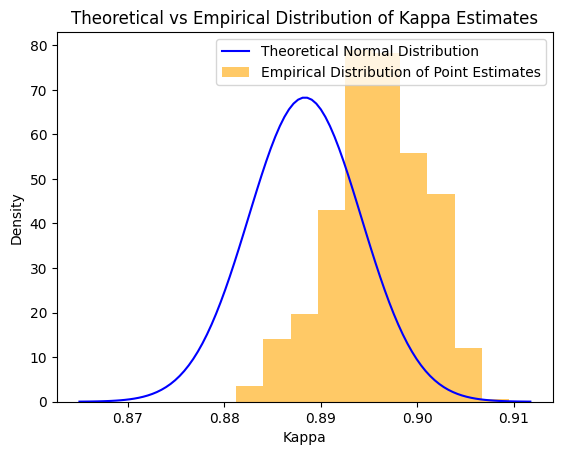

In [49]:
#Visualize the two distributions
fig, ax = plt.subplots()
#theoretical normal distribution
theoretical_mean = point_estimate_kappa
theoretical_std = standard_error
x = np.linspace(theoretical_mean - 4*theoretical_std, theoretical_mean + 4*theoretical_std, 100)
y = (1 / (theoretical_std * np.sqrt(2 * np.pi))) * np.exp( -0.5 * ((x - theoretical_mean) / theoretical_std)**2)
ax.plot(x, y, label='Theoretical Normal Distribution', color='blue')
# add histogram of point estimates
ax.hist(point_estimates, bins=10, density=True, alpha=0.6, color='orange', label='Empirical Distribution of Point Estimates')
ax.set_title('Theoretical vs Empirical Distribution of Kappa Estimates')
ax.set_xlabel('Kappa')
ax.set_ylabel('Density')
ax.legend()
plt.show()

## Bootstrap

In [106]:
def estimate_single_config_bootstrap(X, y, window_size, n_lags, lambda_val, n_bootstrap=1000, 
                                    standardize=True, verbose=False, save_only_positve_r_squared=True):
    """
    Estimate 1st and 2nd stage for a single configuration with bootstrap for kappa distribution.
    
    Parameters
    ----------
    X : array-like
        Features
    y : array-like
        Target variable
    window_size : int
        Rolling window size
    n_lags : int
        Number of lags
    lambda_val : float
        Lasso regularization parameter
    n_bootstrap : int
        Number of bootstrap iterations
    standardize : bool
        Whether to standardize features
    verbose : bool
        Print progress
    save_only_positve_r_squared : bool
        Only save details if R2 is positive
        
    Returns
    -------
    dict with keys:
      - 'summary': dict of scalar metrics (original estimate)
      - 'details': DataFrame of time-series coefficients (Lasso + OLS)
      - 'bootstrap_kappas': array of bootstrap kappa estimates
      - 'bootstrap_summary': dict with bootstrap statistics
    """
    try:
        # ============================================================
        # ORIGINAL ESTIMATION (Stage 1 + Stage 2)
        # ============================================================
        
        # Stage 1: Rolling LASSO + OLS
        stage1_results = lasso_rolling_window(
            X=X, y=y, 
            window_size=window_size, 
            n_lags=n_lags,
            lambda_mode="fixed", 
            fixed_lambda=lambda_val, 
            verbose=False,
            standardize=standardize
        )
        
        # Extract predictions and align data
        preds = np.array(stage1_results["predictions"])
        preds = preds[:-2]  # Remove last two predictions to align with y
        y_valid = y[-len(preds)-1:-1]  # Align with predictions
        y_vals = y_valid.values if isinstance(y_valid, (pd.Series, pd.DataFrame)) else y_valid
        
        # Define de-meaned y for comparing with stage 1 errors
        y_demeaned = y_vals - np.nanmean(y_vals)
        
        # Calculate residuals from original stage 1
        residuals = y_demeaned - preds
        
        # Stage 1 Metrics
        r2_oos_stage1 = calculate_r_squared(y_demeaned, preds)
        r2_insample_stage1 = np.nanmean(stage1_results['insample_r_squareds'])

        # Stage 2 Estimation (Original)
        stage2_input = pd.DataFrame({"vwretd": y_vals, "predictions": preds})
        stage2_results = compute_stage2_r_squared(stage2_input, min_train_size=100)
        
        # ============================================================
        # BOOTSTRAP PROCEDURE
        # ============================================================
        
        bootstrap_kappas = []
        bootstrap_r2_oos_stage2 = []
        bootstrap_r2_insample_stage2 = []
        
        if verbose:
            print(f"Running {n_bootstrap} bootstrap iterations...")
        
        for b in range(n_bootstrap):
            # Generate random multipliers from standard normal
            random_multipliers = np.random.normal(0,1, len(residuals))
            
            # Create bootstrapped residuals
            bootstrap_residuals = residuals * random_multipliers
            
            # Construct synthetic return series: predictions + bootstrapped residuals
            y_synthetic = preds + bootstrap_residuals + y.mean()  # Add back mean to maintain level
            y_synthetic = np.concatenate([y[:-(len(preds))], y_synthetic])  # Reconstruct full y with synthetic tail

            # Re-run Stage 1 on synthetic data
            # Note: We use the same X and predictions structure but with synthetic y
            stage1_bootstrap = lasso_rolling_window(
                X=X, 
                y=y_synthetic,  # Reconstruct full y with synthetic tail
                window_size=window_size, 
                n_lags=n_lags,
                lambda_mode="fixed", 
                fixed_lambda=lambda_val, 
                verbose=False,
                standardize=standardize
            )
    
            # Extract bootstrap predictions
            preds_bootstrap = np.array(stage1_bootstrap["predictions"])
            preds_bootstrap = preds_bootstrap[:-2]
            y_valid_bootstrap = y_synthetic[-len(preds_bootstrap)-1:-1]  # Align with predictions
            
            # Stage 2 on bootstrap sample
            stage2_bootstrap_input = pd.DataFrame({
                "vwretd": y_valid_bootstrap, 
                "predictions": preds_bootstrap
            })
            stage2_bootstrap = compute_stage2_r_squared(stage2_bootstrap_input, min_train_size=100)
            
            # Store bootstrap kappa
            bootstrap_kappas.append(stage2_bootstrap['kappa'])
            bootstrap_r2_oos_stage2.append(stage2_bootstrap['r2_oos'])
            bootstrap_r2_insample_stage2.append(stage2_bootstrap['r2_insample'])
            
            if verbose and (b + 1) % 100 == 0:
                print(f"Completed {b + 1}/{n_bootstrap} bootstrap iterations")
        
        bootstrap_kappas = np.array(bootstrap_kappas)
        bootstrap_r2_oos_stage2 = np.array(bootstrap_r2_oos_stage2)
        bootstrap_r2_insample_stage2 = np.array(bootstrap_r2_insample_stage2)
        
        # Remove NaN values for statistics
        bootstrap_kappas_valid = bootstrap_kappas[~np.isnan(bootstrap_kappas)]
        
        # Bootstrap summary statistics
        bootstrap_summary = {
            'kappa_mean': np.mean(bootstrap_kappas_valid) if len(bootstrap_kappas_valid) > 0 else np.nan,
            'kappa_std': np.std(bootstrap_kappas_valid) if len(bootstrap_kappas_valid) > 0 else np.nan,
            'kappa_median': np.median(bootstrap_kappas_valid) if len(bootstrap_kappas_valid) > 0 else np.nan,
            'kappa_q025': np.percentile(bootstrap_kappas_valid, 2.5) if len(bootstrap_kappas_valid) > 0 else np.nan,
            'kappa_q975': np.percentile(bootstrap_kappas_valid, 97.5) if len(bootstrap_kappas_valid) > 0 else np.nan,
            'kappa_q05': np.percentile(bootstrap_kappas_valid, 5) if len(bootstrap_kappas_valid) > 0 else np.nan,
            'kappa_q95': np.percentile(bootstrap_kappas_valid, 95) if len(bootstrap_kappas_valid) > 0 else np.nan,
            'n_bootstrap': n_bootstrap,
            'n_valid_bootstrap': len(bootstrap_kappas_valid),
            'r2_oos_stage2_mean': np.nanmean(bootstrap_r2_oos_stage2),
            'r2_insample_stage2_mean': np.nanmean(bootstrap_r2_insample_stage2)
        }
        
        # ============================================================
        # BUILD SUMMARY AND DETAILS (ORIGINAL ESTIMATION)
        # ============================================================
        
        summary = {
            'window_size': window_size,
            'n_lags': n_lags,
            'lambda': lambda_val,
            'r2_insample_stage1': r2_insample_stage1,
            'r2_oos_stage1': r2_oos_stage1,
            'r2_insample_stage2': stage2_results['r2_insample'],
            'r2_oos_stage2': stage2_results['r2_oos'],
            'kappa': stage2_results['kappa'],
            'kappa_tstat': stage2_results['kappa_tstat'],
            'intercept': stage2_results['intercept'],
            'intercept_tstat': stage2_results['intercept_tstat'],
            'n_observations': len(y_vals),
            'n_windows': len(stage1_results['predictions']),
            'n_oos_predictions_stage2': stage2_results.get('n_oos_predictions', np.nan)
        }
        
        # Build Detailed Coefficients DataFrame
        n_wins = len(stage1_results['lambdas'])
        dates = stage1_results.get('window_end_dates', np.arange(n_wins))
        features = stage1_results['feature_names']
        detail_rows = []
        
        if save_only_positve_r_squared and summary['r2_insample_stage2'] <= 0:
            detail_rows.append({
                'date': None,
                'window_size': window_size,
                'n_lags': n_lags,
                'lambda': lambda_val,
                'window_index': None,
                'lasso_intercept': np.nan,
                'lasso_r2_in': np.nan,
                'prediction_error': np.nan,
                'num_nonzero_coefficients': np.nan
            })
        else:
            lasso_coefs_arr = stage1_results['coefficients']
            
            for i in range(n_wins):
                row = {
                    'date': dates[i] if i < len(dates) else None,
                    'window_size': window_size,
                    'n_lags': n_lags,
                    'lambda': lambda_val,
                    'window_index': i,
                    'lasso_intercept': stage1_results['intercepts'][i],
                    'lasso_r2_in': stage1_results['insample_r_squareds'][i],
                    'num_nonzero_coefficients': stage1_results['num_nonzero_coefficients'][i]
                }

                for f_idx, f_name in enumerate(features):
                    row[f"Lasso_{f_name}"] = lasso_coefs_arr[i, f_idx]

                detail_rows.append(row)
        
        details_df = pd.DataFrame(detail_rows)
        
        return {
            'summary': summary, 
            'details': details_df,
            'bootstrap_kappas': bootstrap_kappas,
            'bootstrap_summary': bootstrap_summary
        }
        
    except Exception as e:
        error_summary = {
            'window_size': window_size,
            'n_lags': n_lags,
            'lambda': lambda_val,
            'error': str(e),
            'kappa': np.nan, 
            'r2_oos_stage2': np.nan
        }
        return {
            'summary': error_summary, 
            'details': pd.DataFrame(),
            'bootstrap_kappas': np.array([]),
            'bootstrap_summary': {}
        }

In [110]:
#testing the bootstrap function with 10 bootstrap iterations
#Estimate kappa and get its confidence interval on the first simulation
# data
df = dataframes[0]
y = df['r'].values
betas = df.filter(like='beta_').values
df = df.drop(columns=['r'])

#drop column if name starts with beta_
X = df.loc[:, ~df.columns.str.startswith('beta_')].values

#drop first column which is index
X = X[:,1:]
dictionary_b = estimate_single_config_bootstrap(X, y, window_size, n_lags, lambda_val=lambda_val, n_bootstrap= 300, standardize=False, verbose=True, save_only_positve_r_squared=False)

Running 300 bootstrap iterations...
Completed 100/300 bootstrap iterations
Completed 200/300 bootstrap iterations
Completed 300/300 bootstrap iterations


In [111]:
dictionary_b['summary']

{'window_size': 300,
 'n_lags': 1,
 'lambda': 1e-05,
 'r2_insample_stage1': np.float64(0.00029327920445327226),
 'r2_oos_stage1': np.float64(0.0033386361482559135),
 'r2_insample_stage2': np.float64(0.028879909334922238),
 'r2_oos_stage2': np.float64(0.011689198498652686),
 'kappa': np.float64(0.8883677645193772),
 'kappa_tstat': np.float64(152.04817731462316),
 'intercept': np.float64(-2.47058763944573e-05),
 'intercept_tstat': np.float64(-0.24042903753515862),
 'n_observations': 9697,
 'n_windows': 9699,
 'n_oos_predictions_stage2': nan}

In [112]:
dictionary_b['bootstrap_summary']

{'kappa_mean': np.float64(0.06360396416150507),
 'kappa_std': np.float64(0.08354392990619286),
 'kappa_median': np.float64(0.014649228345254478),
 'kappa_q025': np.float64(3.461094608533535e-09),
 'kappa_q975': np.float64(0.27507880068094864),
 'kappa_q05': np.float64(1.213674481736823e-08),
 'kappa_q95': np.float64(0.2381759195456717),
 'n_bootstrap': 300,
 'n_valid_bootstrap': 300,
 'r2_oos_stage2_mean': np.float64(-0.000816551810153178),
 'r2_insample_stage2_mean': np.float64(5.141839297664393e-05)}